# Data Exploration

Training data is the historical dat I'm training on (cross-validation) and the actual temperature will be the testing data to test how effective the model is at predicting temperature. X is all the other factors, y is the temperature.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def csv_read(filepath):
    """import csv file"""
    df = pd.read_csv(filepath)

    return df


Getting the X_train data

In [ ]:
from pathlib import Path

#base_dir = Path.cwd()
#data_path = (base_dir / ".." / "data" / "raw" / "RDU_ACTUAL_HISTORICAL.csv").resolve()

#data_path = base_dir / ".." / "data" / "raw" / "RDU_ACTUAL_HISTORICAL.csv"

ACTUAL_PATH  = 'RDU_ACTUAL_HISTORICAL.csv'

historical_temps = pd.read_csv(ACTUAL_PATH)

#historical_temps = pd.read_csv("/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/data/raw/RDU_ACTUAL_HISTORICAL.csv")

# Convert to datetime
for col in ["observation_time_utc", "hour_utc", "observation_time_local", "hour_local"]:
    historical_temps[col] = pd.to_datetime(
        historical_temps[col].astype(str).str[:19], errors="coerce"
    )

# Feature engineering
historical_temps["time"] = historical_temps["hour_local"].dt.time
historical_temps["day"] = historical_temps["observation_time_local"].dt.day
historical_temps["month"] = historical_temps["observation_time_local"].dt.month
historical_temps["year"] = historical_temps["observation_time_local"].dt.year
historical_temps["day"] = historical_temps["observation_time_local"].dt.day

# Data filtration (just Sept 17-30)
sept_historical_temps = historical_temps[historical_temps["month"] == 10].copy()
sept_historical_temps = sept_historical_temps[sept_historical_temps["day"].between(17, 30)].copy()
sept_historical_temps = sept_historical_temps[sept_historical_temps["year"].between(2021, 2026)].copy()

# making y_train
y_col = ["temperature_f"]
y_train = sept_historical_temps[y_col]
y_train.head()

historical_temps.head()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/notebooks/models/linear_regression/../data/raw/RDU_ACTUAL_HISTORICAL.csv'

In [57]:
historical_preds = csv_read("/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/data/raw/NOAA_GFS_FORECAST_HISTORICAL.csv")
print(historical_preds.columns)
historical_preds.head()
historical_preds.info()

cols = ['forecast_date', 'forecast_hour', 'predicted_date_time', 'forecasted_temp', 'forecast_lat', 'forecast_long']
historical_preds.columns = cols
historical_preds.head()

# Convert to datetime
historical_preds["predicted_date_time"] = (
    pd.to_datetime(historical_preds["predicted_date_time"], utc=True)
    .dt.tz_convert("America/New_York")
    .dt.tz_localize(None)
)

# Feature engineering
historical_preds["pred_time"] = historical_preds["predicted_date_time"].dt.time
historical_preds["pred_day(sept)"] = historical_preds["predicted_date_time"].dt.day
historical_preds["pred_year"] = historical_preds["predicted_date_time"].dt.year
historical_preds = historical_preds.drop(columns="predicted_date_time")
historical_preds.head()

# Convert to X_train
model_cols = ['forecast_date', 'forecast_hour', 'forecasted_temp', 'pred_time', 'pred_day(sept)', 'pred_year']
X_train = historical_preds[model_cols]
X_train.head()

Index(['gfs_init_utc', 'forecast_hour', 'valid_time_utc', 'gfs_temp_f',
       'gfs_grid_lat', 'gfs_grid_lon'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gfs_init_utc    930 non-null    object 
 1   forecast_hour   930 non-null    int64  
 2   valid_time_utc  930 non-null    object 
 3   gfs_temp_f      930 non-null    float64
 4   gfs_grid_lat    930 non-null    float64
 5   gfs_grid_lon    930 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 43.7+ KB


,forecast_date,forecast_hour,forecasted_temp,pred_time,pred_day(sept),pred_year
0,2021-09-16 18:00:00,10,72.949989,00:00:00,17,2021
1,2021-09-16 18:00:00,11,71.714247,01:00:00,17,2021
2,2021-09-16 18:00:00,12,71.451069,02:00:00,17,2021
3,2021-09-16 18:00:00,13,69.781917,03:00:00,17,2021
4,2021-09-16 18:00:00,14,69.460841,04:00:00,17,2021


At this point, we have a dataset with all the forecasted temperatures for the past few years over the given dates. What we need now is to add a feature with the actual temperatues. And make a X_test dataset with predicted temperatures for 2026 and y_test with actual temperatures for 2026.

In [58]:
# Making X_test dataset (predicted temperatures for 2026)

preds_2026 = csv_read("/Users/jothigupta/sem_1/AIPI 520/weather-prediction-RDU/data/raw/NOAA_GFS_FORECAST_FUTURE.csv")
preds_2026.columns = cols
preds_2026.head()

# Convert to date time
for col in ["forecast_date", "predicted_date_time"]:
    preds_2026[col] = pd.to_datetime(
        preds_2026[col].astype(str).str[:19], errors="coerce"
    )

# Feature engineering
preds_2026["pred_time"] = preds_2026["predicted_date_time"].dt.time
preds_2026["pred_day(sept)"] = preds_2026["predicted_date_time"].dt.day
preds_2026["pred_year"] = preds_2026["predicted_date_time"].dt.year
preds_2026 = preds_2026.drop(columns="predicted_date_time")

# Convert to X_test
X_test = preds_2026[model_cols]
X_test.head()

,forecast_date,forecast_hour,forecasted_temp,pred_time,pred_day(sept),pred_year
0,2026-09-16 18:00:00,10,69.389924,04:00:00,17,2026
1,2026-09-16 18:00:00,11,68.854451,05:00:00,17,2026
2,2026-09-16 18:00:00,12,67.350587,06:00:00,17,2026
3,2026-09-16 18:00:00,13,66.622139,07:00:00,17,2026
4,2026-09-16 18:00:00,14,65.846943,08:00:00,17,2026


# Time series visualization

pred_year            int32
pred_time           object
forecasted_temp    float64
dtype: object
   pred_year pred_time  forecasted_temp
0       2021  00:00:00        71.667753
1       2021  01:00:00        70.884109
2       2021  02:00:00        63.681385
3       2021  03:00:00        69.271052
4       2021  04:00:00        69.000294


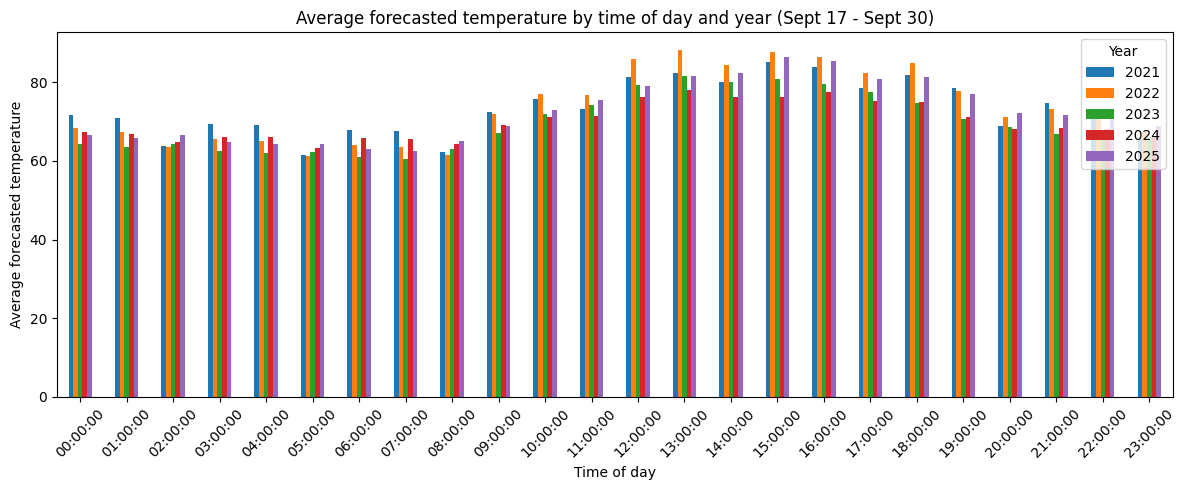

In [59]:
# Group temperature by day and measure average temperature each day
avg_temp_by_time = X_train.groupby(["pred_year", "pred_time"], as_index=False)["forecasted_temp"].mean()

print(avg_temp_by_time.dtypes)
print(avg_temp_by_time.head())

# Reshape so each year becomes its own column
pivot = avg_temp_by_time.pivot(index="pred_time", columns="pred_year", values="forecasted_temp")

# Grouped bar chart: one bar per year at each time of day
pivot.plot(kind="bar", figsize=(12, 5))
plt.title("Average forecasted temperature by time of day and year (Sept 17 - Sept 30)")
plt.xlabel("Time of day")
plt.ylabel("Average forecasted temperature")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.tight_layout()
plt.savefig("../../../reports/figures/Avg_forecasted_temp.png")
plt.show()

pred_year            int32
pred_day(sept)       int32
forecasted_temp    float64
dtype: object
   pred_year  pred_day(sept)  forecasted_temp
0       2021              17        75.573181
1       2021              18        76.631199
2       2021              19        77.839580
3       2021              20        73.649159
4       2021              21        69.958201


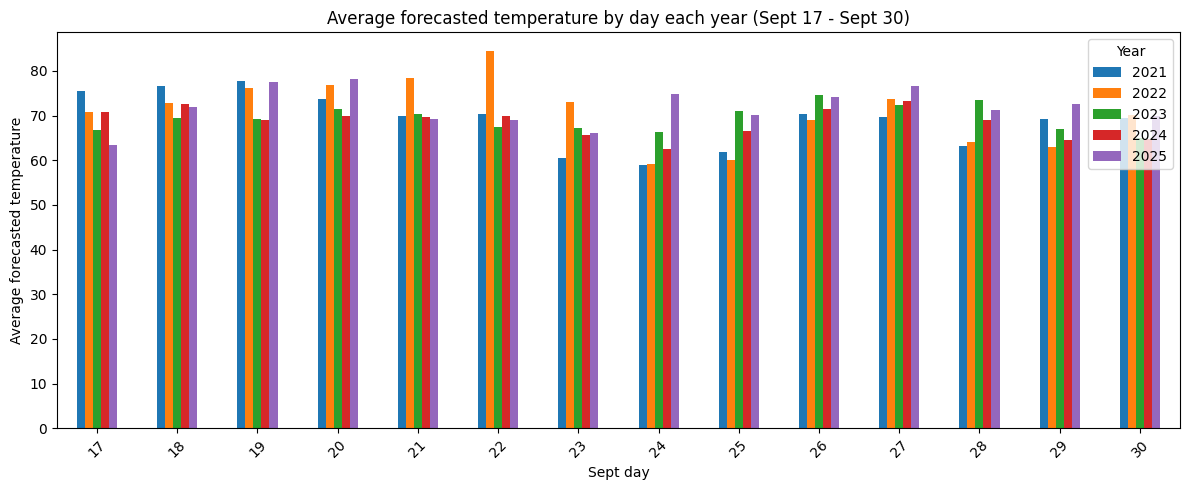

In [60]:
# Group temperature by day and measure average temperature each day
avg_temp_by_day = X_train.groupby(["pred_year", "pred_day(sept)"], as_index=False)["forecasted_temp"].mean()

print(avg_temp_by_day.dtypes)
print(avg_temp_by_day.head())

# Reshape so each year becomes its own column
pivot = avg_temp_by_day.pivot(index="pred_day(sept)", columns="pred_year", values="forecasted_temp")

# Grouped bar chart: one bar per year at each time of day
pivot.plot(kind="bar", figsize=(12, 5))
plt.title("Average forecasted temperature by day each year (Sept 17 - Sept 30)")
plt.xlabel("Sept day")
plt.ylabel("Average forecasted temperature")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

The best lag seems to be 24 hours, so maybe I'll add a feature including the hours since origin.

# Linear Regression Modeling

**Goal:** learn how GFS forecast errors behave at RDU using 2021-2025, then use that to correct the 2026 GFS forecast.

**Setup:** the target (`y`) is the *actual* RDU temperature at the hour each forecast is valid for. The features (`X`) come from the forecast itself: the GFS temperature, how far ahead it was made (`forecast_hour`), and the time of day.

A few notes on how this builds on the cells above:
- The actual temps are matched to forecasts on **valid time** (forecast issue time + `forecast_hour`), so each forecast row gets paired with the actual temperature at that hour.
- The `actual` file ends at 2026-09-17 03:51 UTC, just before the 2026 forecast window starts, so there are no 2026 actuals to build a `y_test` from yet. Instead I evaluate with **leave-one-year-out cross-validation** on 2021-2025.

In [61]:
from sklearn.metrics import mean_absolute_error

# Valid time + time-of-day features (works on both X_train and X_test) ----
def add_time_features(X):
    X = X.copy()
    X["forecast_date"] = pd.to_datetime(X["forecast_date"])   # make sure it is a datetime, not a string
    # valid time = when the forecast was issued + how many hours ahead it looks
    X["valid_time_utc"] = X["forecast_date"] + pd.to_timedelta(X["forecast_hour"], unit="h")
    # hour of day in local (Raleigh) time, encoded as sin/cos so 23:00 and 00:00 are "close"
    local = X["valid_time_utc"].dt.tz_localize("UTC").dt.tz_convert("America/New_York")
    X["hour_sin"] = np.sin(2 * np.pi * local.dt.hour / 24)
    X["hour_cos"] = np.cos(2 * np.pi * local.dt.hour / 24)
    # lets the model trust GFS less the further out it forecasts
    X["gfs_x_lead"] = X["forecasted_temp"] * X["forecast_hour"] / 100
    return X

X_train_full = add_time_features(X_train)
X_test_full  = add_time_features(X_test)

# Actual temperature for each hour
actual = historical_temps[["hour_utc", "temperature_f"]].dropna().copy()
actual["valid_time_utc"] = actual["hour_utc"]   # already UTC and tz-naive (offset was sliced off), matches forecasts
actual = (actual.groupby("valid_time_utc", as_index=False)["temperature_f"].mean()
                .rename(columns={"temperature_f": "actual_temp_f"}))

# Attach actuals to the training forecasts
train = X_train_full.merge(actual, on="valid_time_utc", how="left")
print("training rows:", len(train), "| missing actuals:", train["actual_temp_f"].isna().sum())
train = train.dropna(subset=["actual_temp_f"]).reset_index(drop=True)

# Sanity check: 2026 actuals that overlap the forecast window (expect 0)
print("2026 rows with actuals:", X_test_full.merge(actual, on="valid_time_utc").shape[0])
train.info()

training rows: 930 | missing actuals: 1
2026 rows with actuals: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 929 entries, 0 to 928
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   forecast_date    929 non-null    datetime64[ns]
 1   forecast_hour    929 non-null    int64         
 2   forecasted_temp  929 non-null    float64       
 3   pred_time        929 non-null    object        
 4   pred_day(sept)   929 non-null    int32         
 5   pred_year        929 non-null    int32         
 6   valid_time_utc   929 non-null    datetime64[ns]
 7   hour_sin         929 non-null    float64       
 8   hour_cos         929 non-null    float64       
 9   gfs_x_lead       929 non-null    float64       
 10  actual_temp_f    929 non-null    float64       
dtypes: datetime64[ns](2), float64(5), int32(2), int64(1), object(1)
memory usage: 72.7+ KB


## Candidate models

Starting simple and adding features one group at a time, so we can see which ones actually help.

In [62]:
feature_sets = {
    "A: GFS temp only":           ["forecasted_temp"],
    "B: + forecast_hour":         ["forecasted_temp", "forecast_hour"],
    "C: + time of day":           ["forecasted_temp", "forecast_hour", "hour_sin", "hour_cos"],
    "D: + GFS x lead time":       ["forecasted_temp", "gfs_x_lead", "forecast_hour", "hour_sin", "hour_cos"],
}

y = train["actual_temp_f"]

def score(y_true, y_pred):
    return {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE":  mean_absolute_error(y_true, y_pred),
            "R2":   r2_score(y_true, y_pred)}

# Baseline: the raw GFS forecast (no model)
results = [{"model": "Baseline: raw GFS", **score(y, train["forecasted_temp"])}]

# Leave-one-year-out cross-validation: train on 4 years, test on the 5th, repeat
oof_preds = {}
for name, cols in feature_sets.items():
    preds = pd.Series(index=train.index, dtype=float)
    for yr in sorted(train["pred_year"].unique()):
        is_test = train["pred_year"] == yr
        model = LinearRegression().fit(train.loc[~is_test, cols], y[~is_test])
        preds[is_test] = model.predict(train.loc[is_test, cols])
    oof_preds[name] = preds
    results.append({"model": name, **score(y, preds)})

cv_results = pd.DataFrame(results).set_index("model").round(3)
cv_results

,RMSE,MAE,R2
model,,,
Baseline: raw GFS,5.753,4.303,0.491
A: GFS temp only,5.285,4.008,0.570
B: + forecast_hour,5.384,4.043,0.554
C: + time of day,5.086,3.809,0.602
D: + GFS x lead time,4.971,3.749,0.620


Lower RMSE/MAE and higher R² is better. Anything that beats the **raw GFS baseline** is adding value on top of the forecast.

In [63]:
# ---- Fit the best model on all of 2021-2025 and inspect it ----
best_name = cv_results.drop("Baseline: raw GFS")["RMSE"].idxmin()
best_cols = feature_sets[best_name]
print("Best model:", best_name)

final_model = LinearRegression().fit(train[best_cols], y)
coefs = pd.Series(final_model.coef_, index=best_cols)
print(coefs.round(4))
print("intercept:", round(final_model.intercept_, 3))

Best model: D: + GFS x lead time
forecasted_temp    0.7150
gfs_x_lead        -0.1400
forecast_hour      0.0910
hour_sin          -1.5565
hour_cos          -3.1320
dtype: float64
intercept: 22.359


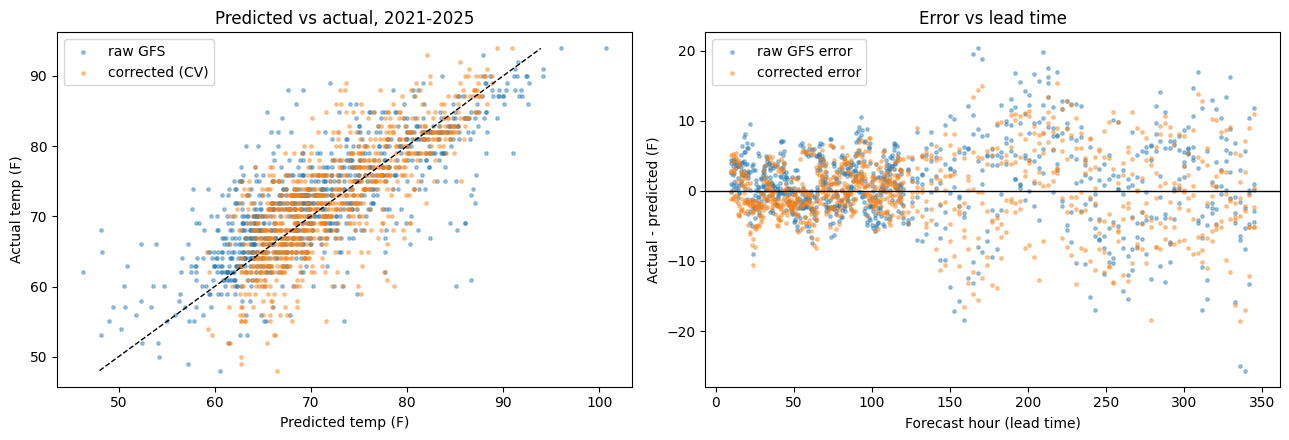

,raw GFS,model
forecast_hour,,
"(0, 48]",3.14,2.98
"(48, 120]",3.60,2.99
"(120, 240]",8.26,6.92
"(240, 400]",7.78,6.96


In [64]:
# ---- Diagnostics ----
best_oof = oof_preds[best_name]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Predicted vs actual
ax[0].scatter(train["forecasted_temp"], y, s=6, alpha=0.4, label="raw GFS")
ax[0].scatter(best_oof, y, s=6, alpha=0.4, label="corrected (CV)")
lims = [y.min(), y.max()]
ax[0].plot(lims, lims, "k--", lw=1)
ax[0].set(xlabel="Predicted temp (F)", ylabel="Actual temp (F)", title="Predicted vs actual, 2021-2025")
ax[0].legend()

# Error by lead time
ax[1].scatter(train["forecast_hour"], y - train["forecasted_temp"], s=6, alpha=0.4, label="raw GFS error")
ax[1].scatter(train["forecast_hour"], y - best_oof, s=6, alpha=0.4, label="corrected error")
ax[1].axhline(0, color="k", lw=1)
ax[1].set(xlabel="Forecast hour (lead time)", ylabel="Actual - predicted (F)", title="Error vs lead time")
ax[1].legend()

plt.tight_layout()
plt.show()

# RMSE by lead-time bucket
bucket = pd.cut(train["forecast_hour"], [0, 48, 120, 240, 400])
rmse = lambda e: np.sqrt((e ** 2).mean())
pd.DataFrame({
    "raw GFS": (y - train["forecasted_temp"]).groupby(bucket, observed=True).apply(rmse),
    "model":   (y - best_oof).groupby(bucket, observed=True).apply(rmse),
}).round(2)

## Predictions for 2026

Applying the fitted model to the 2026 GFS forecast. There are no 2026 actuals yet to score these against; once the actual data is re-pulled through Oct 1, they can be merged on `valid_time_utc` and scored with the same `score()` function.

,valid_time_utc,forecast_hour,forecasted_temp,predicted_temp_f
0,2026-09-17 04:00:00,10,69.389924,68.780961
1,2026-09-17 05:00:00,11,68.854451,68.104106
2,2026-09-17 06:00:00,12,67.350587,66.986226
3,2026-09-17 07:00:00,13,66.622139,66.650756
4,2026-09-17 08:00:00,14,65.846943,66.510745


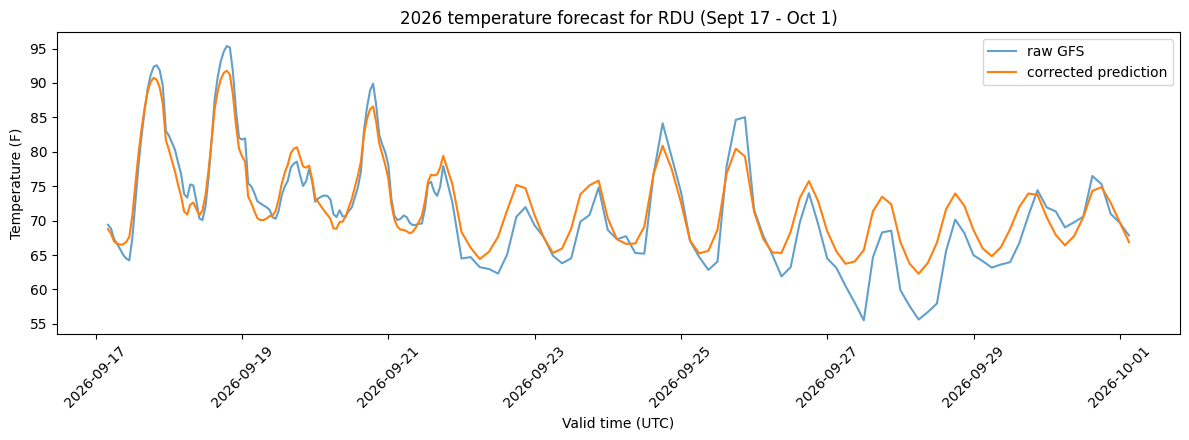

In [65]:
X_test_full["predicted_temp_f"] = final_model.predict(X_test_full[best_cols])

pred_2026 = X_test_full[["valid_time_utc", "forecast_hour", "forecasted_temp", "predicted_temp_f"]]
display(pred_2026.head())

plt.figure(figsize=(12, 4.5))
plt.plot(pred_2026["valid_time_utc"], pred_2026["forecasted_temp"], label="raw GFS", alpha=0.7)
plt.plot(pred_2026["valid_time_utc"], pred_2026["predicted_temp_f"], label="corrected prediction")
plt.title("2026 temperature forecast for RDU (Sept 17 - Oct 1)")
plt.xlabel("Valid time (UTC)"); plt.ylabel("Temperature (F)")
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

#pred_2026.to_csv("..figures/rdu_2026_predictions.csv", index=False)   # uncomment to save

In [66]:
import pandas as pd
url = ("https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
       "?station=RDU&data=tmpf"
       "&year1=2026&month1=9&day1=16&year2=2026&month2=10&day2=2"
       "&tz=America%2FNew_York&format=onlycomma&latlon=no&missing=M&trace=T"
       "&direct=no&report_type=3&report_type=4")
obs = pd.read_csv(url)
obs['time'] = pd.to_datetime(obs['valid']).dt.round('h')
obs['tmpf'] = pd.to_numeric(obs['tmpf'], errors='coerce')
test = (obs.dropna(subset=['tmpf']).groupby('time', as_index=False)['tmpf'].mean()
           .rename(columns={'tmpf': 'actual_temp'}))
test = test[(test['time'] >= '2026-09-17 00:00') & (test['time'] <= '2026-09-30 23:00')]
test.to_csv('RDU_TEST_SEP17_30.csv', index=False)
print(len(test), 'hours |', test['time'].min(), '->', test['time'].max())

# The mesonet request used tz=America/New_York, so 'time' is LOCAL. Convert to UTC (tz-naive) so it
# lines up with valid_time_utc on the forecasts.
test = test.copy()
test["valid_time_utc"] = (test["time"].dt.tz_localize("America/New_York")
                                      .dt.tz_convert("UTC")
                                      .dt.tz_localize(None))

# setting up y_test data
y_col = ["actual_temp"]
y_test = test[y_col]

336 hours | 2026-09-17 00:00:00 -> 2026-09-30 23:00:00


In [67]:
# Testing the model on 2026
# Align forecasts and actuals on valid time (inner join keeps only hours that have both),
# so X_test and y_test always have the same rows in the same order.
test_df = X_test_full.merge(test[["valid_time_utc", "actual_temp"]], on="valid_time_utc", how="inner")
print("2026 forecast rows:", len(X_test_full), "| actual hours:", len(test), "| matched rows:", len(test_df))

y_test = test_df["actual_temp"]
test_df["predicted_temp_f"] = final_model.predict(test_df[best_cols])

test_results = pd.DataFrame([
    {"model": "Baseline: raw GFS",           **score(y_test, test_df["forecasted_temp"])},
    {"model": f"{best_name} (LinearReg)",    **score(y_test, test_df["predicted_temp_f"])},
]).set_index("model").round(3)
test_results

2026 forecast rows: 186 | actual hours: 336 | matched rows: 186


,RMSE,MAE,R2
model,,,
Baseline: raw GFS,6.798,5.157,0.543
D: + GFS x lead time (LinearReg),6.521,5.190,0.580


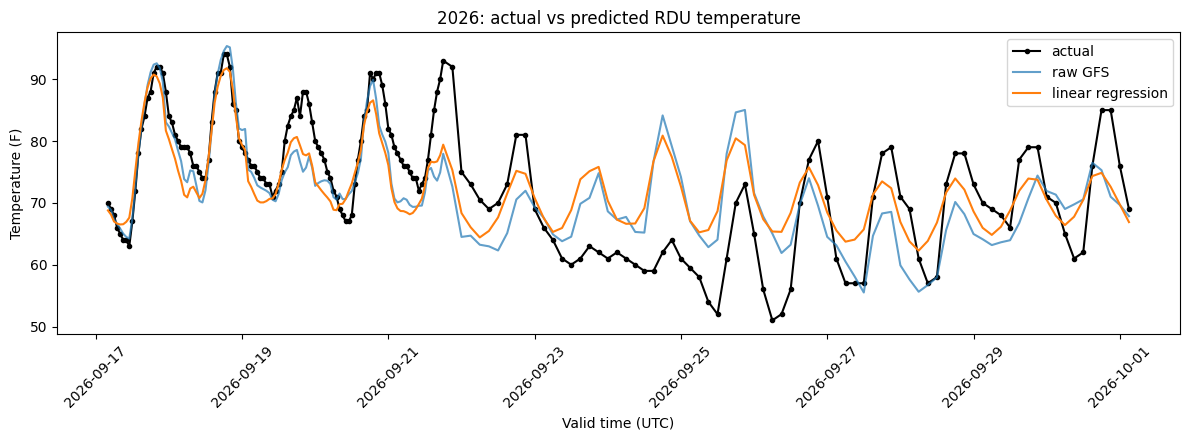

In [68]:
plt.figure(figsize=(12, 4.5))
t = test_df.sort_values("valid_time_utc")
plt.plot(t["valid_time_utc"], t["actual_temp"], "k.-", label="actual")
plt.plot(t["valid_time_utc"], t["forecasted_temp"], alpha=0.7, label="raw GFS")
plt.plot(t["valid_time_utc"], t["predicted_temp_f"], label="linear regression")
plt.title("2026: actual vs predicted RDU temperature")
plt.xlabel("Valid time (UTC)"); plt.ylabel("Temperature (F)")
plt.xticks(rotation=45); plt.legend(); plt.tight_layout()
plt.savefig("../../../reports/figures/lr_test.png")
plt.show()